In [11]:
analysis_year = 2023
metro_rel_path = "Data/Metro/서울교통공사_역별 시간대별 승하차인원(23.1~23.12) (1).csv"

In [12]:
from pathlib import Path
import platform

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

project_root = Path.cwd().resolve()
if not (project_root / metro_rel_path).exists() and (project_root.parent / metro_rel_path).exists():
    project_root = project_root.parent

if platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False


In [13]:
metro_path = project_root / metro_rel_path
subway_df = pd.read_csv(metro_path, encoding="cp949")

station_col = "역명"
direction_col = "승하차구분" if "승하차구분" in subway_df.columns else "구분"
date_col = "수송일자" if "수송일자" in subway_df.columns else "날짜"

selected_stations = ["여의도", "여의나루"]
time_order = [
    "06시이전", "06시 이전", "06-07시간대", "06시-07시", "07-08시간대", "07시-08시",
    "08-09시간대", "08시-09시", "09-10시간대", "09시-10시", "10-11시간대", "10시-11시",
    "11-12시간대", "11시-12시", "12-13시간대", "12시-13시", "13-14시간대", "13시-14시",
    "14-15시간대", "14시-15시", "15-16시간대", "15시-16시", "16-17시간대", "16시-17시",
    "17-18시간대", "17시-18시", "18-19시간대", "18시-19시", "19-20시간대", "19시-20시",
    "20-21시간대", "20시-21시", "21-22시간대", "21시-22시", "22-23시간대", "22시-23시",
    "23-24시간대", "23시-24시", "24시이후", "24시 이후"
]
hour_cols = [col for col in time_order if col in subway_df.columns]

filtered_df = subway_df[subway_df[station_col].isin(selected_stations)].copy()
filtered_df[date_col] = pd.to_datetime(filtered_df[date_col])
filtered_df["날짜타입"] = filtered_df[date_col].dt.weekday.map(lambda x: "주말" if x >= 5 else "평일")
cleaned_df = filtered_df[[station_col, date_col, "날짜타입", direction_col] + hour_cols].copy()
display(cleaned_df.head())


,역명,수송일자,날짜타입,승하차구분,06시이전,06-07시간대,07-08시간대,08-09시간대,09-10시간대,10-11시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시이후
272,여의도,2023-01-01,주말,승차,40,59,74,134,131,166,...,424,540,561,483,375,404,422,234,55,0
273,여의도,2023-01-01,주말,하차,32,136,286,295,351,351,...,463,497,443,313,222,129,125,109,54,28
274,여의나루,2023-01-01,주말,승차,35,48,69,439,140,142,...,364,442,491,408,316,275,227,138,30,0
275,여의나루,2023-01-01,주말,하차,36,248,422,176,200,293,...,374,438,452,315,188,167,89,62,26,3
818,여의도,2023-01-02,평일,승차,62,114,376,558,352,354,...,1288,1678,6290,8667,2994,2344,1848,1020,300,40


In [14]:
station_avg_df = (
    cleaned_df
    .groupby([station_col, "날짜타입", direction_col], as_index=False)[hour_cols]
    .mean()
)

median_df = station_avg_df.melt(
    id_vars=[station_col, "날짜타입", direction_col],
    value_vars=hour_cols,
    var_name="시간",
    value_name="평균값",
)
time_order_map = {column: idx for idx, column in enumerate(hour_cols)}
median_df["시간_순서"] = median_df["시간"].map(time_order_map)
median_df = (
    median_df
    .groupby(["날짜타입", direction_col, "시간", "시간_순서"], as_index=False)["평균값"]
    .median()
    .rename(columns={"평균값": "중앙값"})
    .sort_values(["날짜타입", direction_col, "시간_순서"])
    .reset_index(drop=True)
)

display(station_avg_df.head())
display(median_df.head())


,역명,날짜타입,승하차구분,06시이전,06-07시간대,07-08시간대,08-09시간대,09-10시간대,10-11시간대,11-12시간대,...,15-16시간대,16-17시간대,17-18시간대,18-19시간대,19-20시간대,20-21시간대,21-22시간대,22-23시간대,23-24시간대,24시이후
0,여의나루,주말,승차,39.380952,64.723810,70.161905,133.057143,137.361905,239.790476,318.371429,...,908.942857,1252.190476,1398.780952,1443.800000,1470.180952,1787.800000,1553.857143,1155.838095,390.428571,3.780952
1,여의나루,주말,하차,41.466667,270.952381,339.428571,495.171429,580.342857,952.542857,1129.323810,...,1778.571429,1789.200000,1661.742857,1330.857143,858.476190,511.723810,304.771429,169.038095,95.495238,10.104762
2,여의나루,평일,승차,42.057692,92.796154,234.646154,365.307692,213.565385,175.600000,232.234615,...,679.776923,1001.884615,2062.853846,2706.642308,1187.603846,1250.534615,996.126923,765.996154,298.230769,39.180769
3,여의나루,평일,하차,55.123077,503.326923,1718.900000,3143.188462,1186.915385,706.065385,593.734615,...,746.292308,783.692308,929.223077,1097.319231,644.038462,371.996154,246.926923,171.930769,88.307692,37.088462
4,여의도,주말,승차,58.342857,84.019048,116.466667,189.866667,230.552381,303.685714,397.142857,...,1107.895238,1389.580952,1379.333333,1208.180952,1088.704762,1391.295238,1027.476190,538.866667,143.228571,1.990476


,날짜타입,승하차구분,시간,시간_순서,중앙값
0,주말,승차,06시이전,0,48.861905
1,주말,승차,06-07시간대,1,74.371429
2,주말,승차,07-08시간대,2,93.314286
3,주말,승차,08-09시간대,3,161.461905
4,주말,승차,09-10시간대,4,183.957143


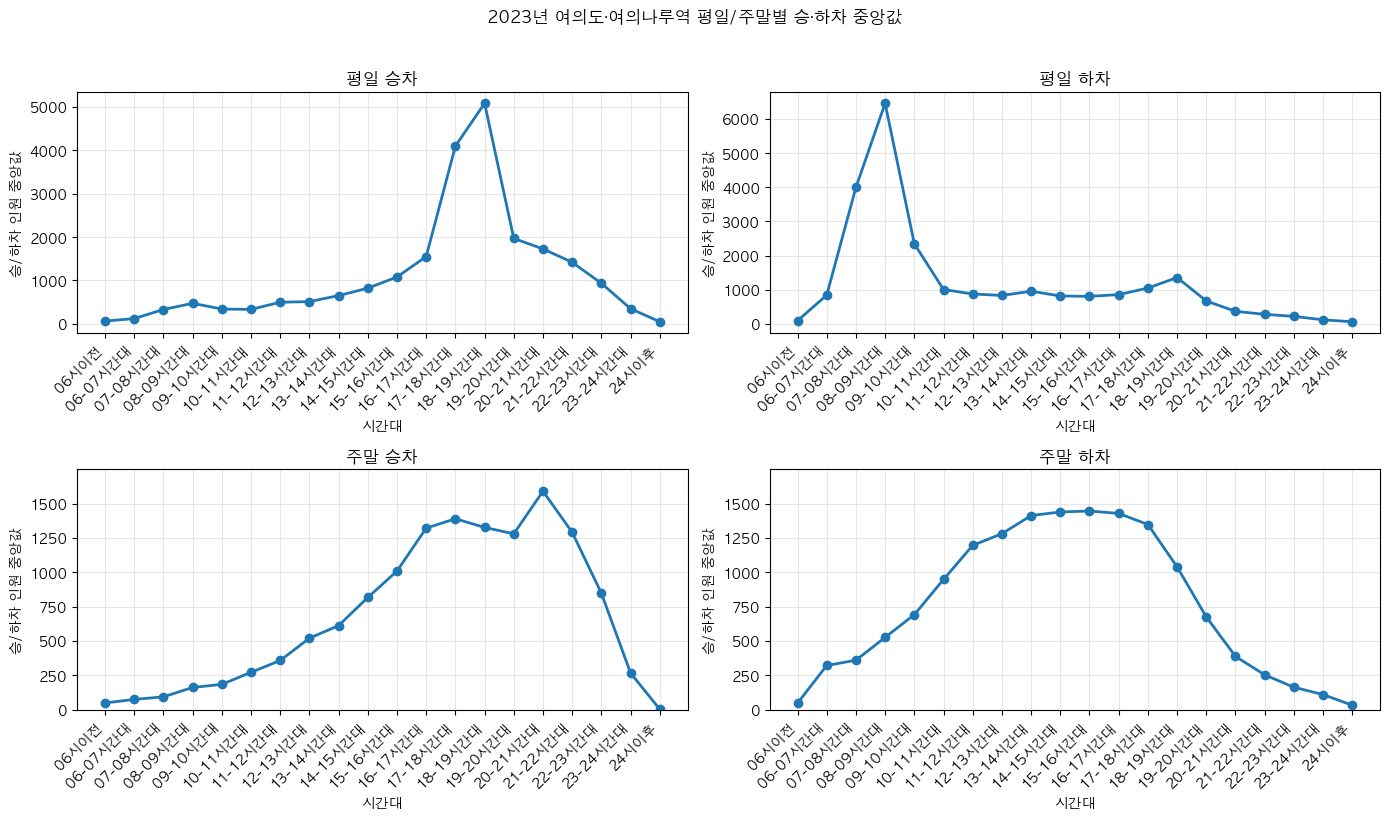

In [15]:
plot_order = [("평일", "승차"), ("평일", "하차"), ("주말", "승차"), ("주말", "하차")]
weekend_max = median_df[median_df["날짜타입"] == "주말"]["중앙값"].max()
weekend_ymax = weekend_max * 1.1 if pd.notna(weekend_max) else None

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharey=False)

for ax, (date_type, direction) in zip(axes.flatten(), plot_order):
    subset = median_df[(median_df["날짜타입"] == date_type) & (median_df[direction_col] == direction)].sort_values("시간_순서")
    ax.plot(subset["시간_순서"], subset["중앙값"], marker="o", linewidth=2)
    ax.set_title(f"{date_type} {direction}")
    ax.set_xlabel("시간대")
    ax.set_ylabel("승/하차 인원 중앙값")
    ax.set_xticks(range(len(hour_cols)))
    ax.set_xticklabels(hour_cols, rotation=45, ha="right")
    if date_type == "주말" and weekend_ymax is not None:
        ax.set_ylim(0, weekend_ymax)
    ax.grid(alpha=0.3)

fig.suptitle(f"{analysis_year}년 여의도·여의나루역 평일/주말별 승·하차 중앙값", y=1.02)
fig.tight_layout()
plt.show()


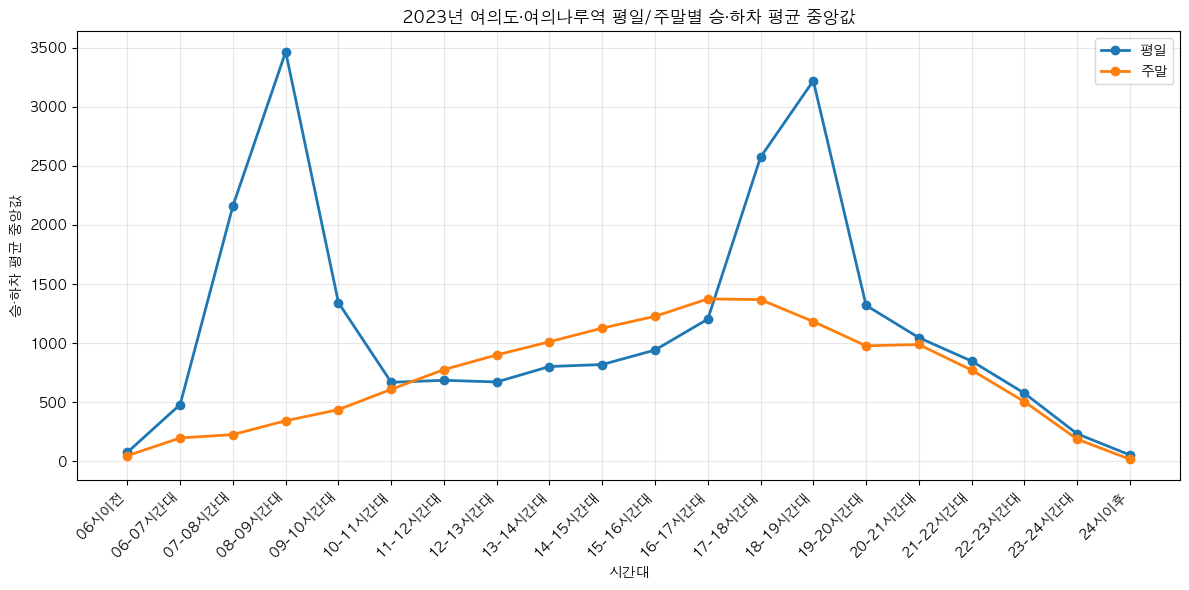

In [16]:
# Combined Weekday/Weekend Summary
combined_station_avg_df = (
    station_avg_df
    .groupby([station_col, "날짜타입"], as_index=False)[hour_cols]
    .mean()
)

combined_median_df = combined_station_avg_df.melt(
    id_vars=[station_col, "날짜타입"],
    value_vars=hour_cols,
    var_name="시간",
    value_name="평균값",
)
combined_median_df["시간_순서"] = combined_median_df["시간"].map(time_order_map)
combined_median_df = (
    combined_median_df
    .groupby(["날짜타입", "시간", "시간_순서"], as_index=False)["평균값"]
    .median()
    .rename(columns={"평균값": "중앙값"})
    .sort_values(["날짜타입", "시간_순서"])
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
for date_type, color in [("평일", "#1f77b4"), ("주말", "#ff7f0e")]:
    subset = combined_median_df[combined_median_df["날짜타입"] == date_type].sort_values("시간_순서")
    ax.plot(subset["시간_순서"], subset["중앙값"], marker="o", linewidth=2, label=date_type, color=color)

ax.set_title(f"{analysis_year}년 여의도·여의나루역 평일/주말별 승·하차 평균 중앙값")
ax.set_xlabel("시간대")
ax.set_ylabel("승·하차 평균 중앙값")
ax.set_xticks(range(len(hour_cols)))
ax.set_xticklabels(hour_cols, rotation=45, ha="right")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
